# **LIBRERIAS Y DF**

In [ ]:
# Importar las librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
import shap

import warnings
warnings.filterwarnings("ignore")

#Regresión Logística binomial
import sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split #Train / Test Split
from sklearn.impute import SimpleImputer #Imputación de los datos
from sklearn.metrics import accuracy_score #accuracy
from sklearn import metrics #matriz de confusión
from sklearn.metrics import precision_score, recall_score, f1_score #matriz de confusión
from sklearn.preprocessing import StandardScaler #Importancia de las Variables

#Curva ROC
from sklearn.metrics import roc_curve, roc_auc_score

#Regresión Logística Enfoque Econométrico
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.proportion import proportions_chisquare
from sklearn.metrics import confusion_matrix, classification_report

#Random Forest
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [ ]:
#Carga del Dataset
df = pd.read_csv("/content/CASPTONE Requerimiento_informacion_udla_uep.csv")
# Visualizar para confirmar la carga correcta
df.head()

,NOMBRE_IES,TIPO_FINANCIAMIENTO,NOMBRE_CARRERA,NIVEL_FORMACION,MODALIDAD,PROVINCIA_RESIDENCIA,ETNIA,DISCAPACIDAD,CAMPO_AMPLIO,EDAD,AÑO,TOTAL,SEXO
0,ESCUELA POLITECNICA NACIONAL,PUBLICA,ADMINISTRACION DE EMPRESAS,CUARTO NIVEL O POSGRADO,PRESENCIAL,NaN,MESTIZO,NINGUNA,ADMINISTRACION,25.00,2017,1,FEMENINO
1,ESCUELA POLITECNICA NACIONAL,PUBLICA,ADMINISTRACION DE EMPRESAS,CUARTO NIVEL O POSGRADO,PRESENCIAL,NaN,MESTIZO,NINGUNA,ADMINISTRACION,26.00,2016,1,FEMENINO
2,ESCUELA POLITECNICA NACIONAL,PUBLICA,ADMINISTRACION DE EMPRESAS,CUARTO NIVEL O POSGRADO,PRESENCIAL,NaN,MESTIZO,NINGUNA,ADMINISTRACION,26.00,2018,1,FEMENINO
3,ESCUELA POLITECNICA NACIONAL,PUBLICA,ADMINISTRACION DE EMPRESAS,CUARTO NIVEL O POSGRADO,PRESENCIAL,NaN,MESTIZO,NINGUNA,ADMINISTRACION,27.00,2017,1,MASCULINO
4,ESCUELA POLITECNICA NACIONAL,PUBLICA,ADMINISTRACION DE EMPRESAS,CUARTO NIVEL O POSGRADO,PRESENCIAL,NaN,MESTIZO,NINGUNA,ADMINISTRACION,28.00,2018,1,FEMENINO


In [ ]:
print (df.shape)

(1328567, 13)


In [ ]:
#Total de registros de base de datos

# Check the total number of records in the DataFrame
total_records = len(df)
print(f"Total de registros en el dataset: {total_records}")

Total de registros en el dataset: 1328567


# **1. ORDEN DE VARIABLES**

In [ ]:
# Eliminar la columna 'TOTAL', no aporta información
if 'TOTAL' in df.columns:
    df = df.drop(columns=['TOTAL'])

In [ ]:
#Listado de variables definitvas
for col in df.columns:
    print(col)

NOMBRE_IES
TIPO_FINANCIAMIENTO
NOMBRE_CARRERA
NIVEL_FORMACION
MODALIDAD
PROVINCIA_RESIDENCIA
ETNIA
DISCAPACIDAD
CAMPO_AMPLIO
EDAD
AÑO
SEXO


In [ ]:
# Lista con el orden deseado de las columnas
column_order = ['AÑO', 'NOMBRE_IES',	'TIPO_FINANCIAMIENTO',	'NOMBRE_CARRERA',	'NIVEL_FORMACION',	'MODALIDAD',	'PROVINCIA_RESIDENCIA',	'ETNIA',	'DISCAPACIDAD',	'CAMPO_AMPLIO', 'SEXO', 'EDAD']

# Reordenar las columnas del DataFrame según el orden definido
df = df[column_order]

# Ajustar las opciones de visualización de pandas
pd.set_option('display.max_columns', None)  # Muestra todas las columnas
pd.set_option('display.max_rows', 10)      # Limita el número de filas mostradas
pd.set_option('display.width', 1000)       # Ajusta el ancho para que no se trunque

# Imprimir el DataFrame
print(df.head(10))

    AÑO                    NOMBRE_IES TIPO_FINANCIAMIENTO              NOMBRE_CARRERA          NIVEL_FORMACION   MODALIDAD PROVINCIA_RESIDENCIA    ETNIA DISCAPACIDAD    CAMPO_AMPLIO       SEXO  EDAD
0  2017  ESCUELA POLITECNICA NACIONAL             PUBLICA  ADMINISTRACION DE EMPRESAS  CUARTO NIVEL O POSGRADO  PRESENCIAL                  NaN  MESTIZO      NINGUNA  ADMINISTRACION   FEMENINO 25.00
1  2016  ESCUELA POLITECNICA NACIONAL             PUBLICA  ADMINISTRACION DE EMPRESAS  CUARTO NIVEL O POSGRADO  PRESENCIAL                  NaN  MESTIZO      NINGUNA  ADMINISTRACION   FEMENINO 26.00
2  2018  ESCUELA POLITECNICA NACIONAL             PUBLICA  ADMINISTRACION DE EMPRESAS  CUARTO NIVEL O POSGRADO  PRESENCIAL                  NaN  MESTIZO      NINGUNA  ADMINISTRACION   FEMENINO 26.00
3  2017  ESCUELA POLITECNICA NACIONAL             PUBLICA  ADMINISTRACION DE EMPRESAS  CUARTO NIVEL O POSGRADO  PRESENCIAL                  NaN  MESTIZO      NINGUNA  ADMINISTRACION  MASCULINO 27.00
4  20

# **2. ANÁLSIS DESCRIPTIVO Y EXPLORATORIOS DE LOS DATOS**

**2.1 Datos Perdidos**

In [ ]:
df.isna().sum()

,0
AÑO,0
NOMBRE_IES,0
TIPO_FINANCIAMIENTO,0
NOMBRE_CARRERA,0
NIVEL_FORMACION,0
...,...
ETNIA,0
DISCAPACIDAD,0
CAMPO_AMPLIO,0
SEXO,0


In [ ]:
no_definido_count = df.apply(lambda x: x.astype(str).str.contains('NO_DEFINIDO', case=False, na=False).sum()).sum()
no_aplica_count = df.apply(lambda x: x.astype(str).str.contains('NO_APLICA', case=False, na=False).sum()).sum()
no_registra_count = df.apply(lambda x: x.astype(str).str.contains('NO_REGISTRA', case=False, na=False).sum()).sum()
nan_count = df.isna().sum().sum()

print(f"Cantidad de valores 'NO_DEFINIDO': {no_definido_count}")
print(f"Cantidad de valores 'NO_APLICA': {no_aplica_count}")
print(f"Cantidad de valores 'NO_REGISTRA': {no_registra_count}")
print(f"Cantidad de valores NaN: {nan_count}")

Cantidad de valores 'NO_DEFINIDO': 7853
Cantidad de valores 'NO_APLICA': 6942
Cantidad de valores 'NO_REGISTRA': 179932
Cantidad de valores NaN: 19653


In [ ]:
# Reemplazar valores NO_DEFINIDO, NO_APLICA, NO_REGISTRA, NaN con la moda en las columnas categóricas
for column in ['PROVINCIA_RESIDENCIA', 'ETNIA', 'CAMPO_AMPLIO']:
    if column in df.columns:
        moda = df[column].mode()[0]  # Calcular la moda de la columna
        df[column] = df[column].replace(['NO_DEFINIDO', 'NO_APLICA', 'NO_REGISTRA','NaN'], moda)

# Corregir valores en la columna EDAD mayores a 90 años y menores a 17 años
if 'EDAD' in df.columns:
    mediana_edad = df['EDAD'].median()  # Calcular la mediana de la columna
    df['EDAD'] = df['EDAD'].apply(lambda x: mediana_edad if x < 17 or x > 60 else x) #se considera los 60 como la edad máxima para evitar afectar el análisis, los datos >80 tienen un solo registro

# Convertir EDAD a entero después de la limpieza
df['EDAD'] = df['EDAD'].fillna(mediana_edad).astype(int)

# Confirmar que los datos han sido corregidos
print("Correcciones completadas")
print(df[['PROVINCIA_RESIDENCIA', 'ETNIA', 'CAMPO_AMPLIO', 'EDAD']].head())

Correcciones completadas
  PROVINCIA_RESIDENCIA    ETNIA    CAMPO_AMPLIO  EDAD
0                  NaN  MESTIZO  ADMINISTRACION    25
1                  NaN  MESTIZO  ADMINISTRACION    26
2                  NaN  MESTIZO  ADMINISTRACION    26
3                  NaN  MESTIZO  ADMINISTRACION    27
4                  NaN  MESTIZO  ADMINISTRACION    28


In [ ]:
#Correción de valores NaN en PROVINCIA_RESIDENCIA, ya que al hacer la imputación en el punto previo todavía se observan valores NaN
print(df['PROVINCIA_RESIDENCIA'].isna().sum())

19544


In [ ]:
#Reemplazar con un valor fijo en este caso la moda
moda = df['PROVINCIA_RESIDENCIA'].mode()[0]
df['PROVINCIA_RESIDENCIA'] = df['PROVINCIA_RESIDENCIA'].fillna(moda)

**2.2 Tipo de Variables**

In [ ]:
df.dtypes

,0
AÑO,int64
NOMBRE_IES,object
TIPO_FINANCIAMIENTO,object
NOMBRE_CARRERA,object
NIVEL_FORMACION,object
...,...
ETNIA,object
DISCAPACIDAD,object
CAMPO_AMPLIO,object
SEXO,object


**2.3 Descripción de las variables numéricas**

In [ ]:
# Cambiar la configuración de pandas para mostrar los números sin notación científica
pd.set_option('display.float_format', '{:.2f}'.format)

df.describe(include='int64')

,AÑO,EDAD
count,1328567.00,1328567.00
mean,2019.52,27.63
std,2.58,8.23
min,2015.00,17.00
25%,2017.00,21.00
50%,2020.00,25.00
75%,2022.00,32.00
max,2023.00,60.00


In [ ]:
pd.DataFrame(df["EDAD"].value_counts())

,count
EDAD,
21,92716
22,91634
20,90956
23,86942
19,83389
...,...
56,2167
57,1820
58,1487


In [ ]:
pd.DataFrame(df["AÑO"].value_counts())

,count
AÑO,
2023,203688
2022,181892
2021,169352
2020,154741
2019,142630
2018,130558
2017,118760
2015,114787
2016,112159


**2.4 Descripción de las variables categóricas**

In [ ]:
df.describe(include='object')

,NOMBRE_IES,TIPO_FINANCIAMIENTO,NOMBRE_CARRERA,NIVEL_FORMACION,MODALIDAD,PROVINCIA_RESIDENCIA,ETNIA,DISCAPACIDAD,CAMPO_AMPLIO,SEXO
count,1328567,1328567,1328567,1328567,1328567,1328567,1328567,1328567,1328567,1328567
unique,62,3,2011,5,6,25,8,8,11,2
top,UNIVERSIDAD TECNICA PARTICULAR DE LOJA,PUBLICA,DERECHO,TERCER NIVEL O PREGRADO,PRESENCIAL,PICHINCHA,MESTIZO,NINGUNA,"CIENCIAS SOCIALES, PERIODISMO, INFORMACION Y D...",FEMENINO
freq,149500,704244,87217,970284,919185,291678,985474,1287381,410798,731590


In [ ]:
pd.DataFrame(df["NOMBRE_IES"].value_counts())

,count
NOMBRE_IES,
UNIVERSIDAD TECNICA PARTICULAR DE LOJA,149500
UNIVERSIDAD DE GUAYAQUIL,67541
PONTIFICIA UNIVERSIDAD CATOLICA DEL ECUADOR,58918
UNIVERSIDAD CENTRAL DEL ECUADOR,58143
UNIVERSIDAD ESTATAL DE MILAGRO,56811
...,...
UNIVERSIDAD DEL PACIFICO ESCUELA DE NEGOCIOS,3412
UNIVERSIDAD DE ESPECIALIDADES TURISTICAS,2032
UNIVERSIDAD INTERCULTURAL DE LAS NACIONALIDADES Y PUEBLOS INDIGENAS AMAWTAY WASI,1745


In [ ]:
pd.DataFrame(df["TIPO_FINANCIAMIENTO"].value_counts())

,count
TIPO_FINANCIAMIENTO,
PUBLICA,704244
PARTICULAR COFINANCIADA,383950
PARTICULAR AUTOFINANCIADA,240373


In [ ]:
pd.DataFrame(df["NIVEL_FORMACION"].value_counts())

,count
NIVEL_FORMACION,
TERCER NIVEL O PREGRADO,970284
CUARTO NIVEL O POSGRADO,192563
TERCER NIVEL DE GRADO,153057
TERCER NIVEL TECNICO-TECNOLOGICO SUPERIOR,12653
TERCER NIVEL TECNOLOGICO SUPERIOR UNIVERSITARIO,10


In [ ]:
pd.DataFrame(df["MODALIDAD"].value_counts())

,count
MODALIDAD,
PRESENCIAL,919185
A DISTANCIA,195051
EN LINEA,128966
SEMIPRESENCIAL,66685
HIBRIDA,17456
DUAL,1224


In [ ]:
pd.DataFrame(df["PROVINCIA_RESIDENCIA"].value_counts(28))

,proportion
PROVINCIA_RESIDENCIA,
PICHINCHA,0.22
GUAYAS,0.16
MANABI,0.08
AZUAY,0.05
LOS RIOS,0.04
...,...
ZAMORA CHINCHIPE,0.01
PASTAZA,0.01
ORELLANA,0.01


In [ ]:
pd.DataFrame(df["ETNIA"].value_counts())

,count
ETNIA,
MESTIZO,985474
AFROECUATORIANO,88280
INDIGENA,76301
BLANCO,63768
MONTUBIO,56079
OTRO,49877
MULATO,7011
NEGRO,1777


In [ ]:
pd.DataFrame(df["DISCAPACIDAD"].value_counts())

,count
DISCAPACIDAD,
NINGUNA,1287381
FISICA_MOTORA,19554
VISUAL,10941
AUDITIVA,5740
INTELECTUAL,2691
MENTAL_PSICOSOCIAL,1630
LENGUAJE,629
NO_DEFINIDO,1


In [ ]:
pd.DataFrame(df["CAMPO_AMPLIO"].value_counts())

,count
CAMPO_AMPLIO,
"CIENCIAS SOCIALES, PERIODISMO, INFORMACION Y DERECHO",410798
EDUCACION,196626
"INGENIERIA, INDUSTRIA Y CONSTRUCCION",170675
SALUD Y BIENESTAR,140065
ADMINISTRACION,132772
...,...
SERVICIOS,62125
"AGRICULTURA, SILVICULTURA, PESCA Y VETERINARIA",58919
ARTES Y HUMANIDADES,46140


In [ ]:
pd.DataFrame(df["SEXO"].value_counts())

,count
SEXO,
FEMENINO,731590
MASCULINO,596977


**2.5 Distribución de la variable 'EDAD'**

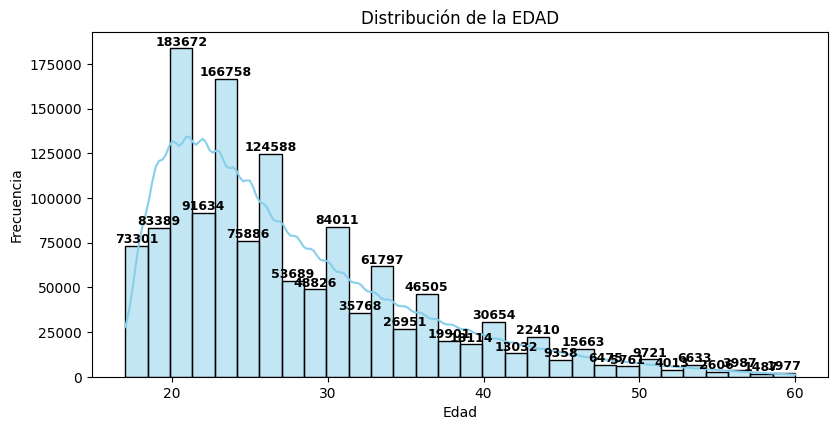

In [ ]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 1)

# Crear el histograma
hist = sns.histplot(df['EDAD'], bins=30, kde=True, color='skyblue')

# Agregar etiquetas a las barras
for bar in hist.patches:
    height = bar.get_height()
    if height > 0:  # Solo mostrar etiquetas si la barra tiene altura
        plt.text(bar.get_x() + bar.get_width() / 2,   # Posición X centrada
                 height,                             # Posición Y en la altura
                 f'{int(height)}',                   # Mostrar el valor entero
                 ha='center', va='bottom',           # Alineación
                 fontsize=9, color='black', weight='bold')

# Configuraciones adicionales
plt.title('Distribución de la EDAD')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()

**2.6 Proporción de valores en 'ETNIA'**

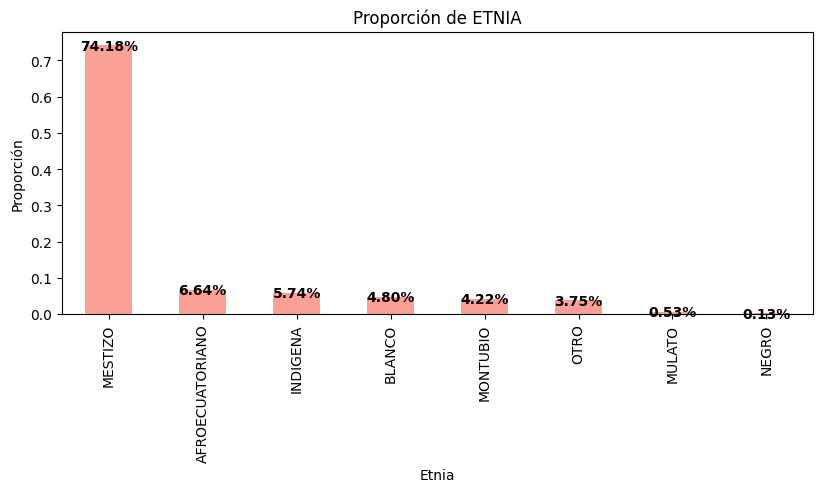

In [ ]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 2)

# Calcular las proporciones de ETNIA
etnia_counts = df['ETNIA'].value_counts(normalize=True)

# Crear el gráfico de barras
bars = etnia_counts.plot(kind='bar', color='salmon', alpha=0.75)

# Agregar etiquetas de datos sobre las barras
for bar in bars.patches:
    plt.text(bar.get_x() + bar.get_width() / 2,   # Posición X centrada
             bar.get_height() - 0.02,             # Posición Y (altura)
             f'{bar.get_height():.2%}',           # Formato como porcentaje
             ha='center', va='bottom',            # Alineación
             fontsize=10, color='black', weight='bold')

# Configuraciones adicionales
plt.title('Proporción de ETNIA')
plt.xlabel('Etnia')
plt.ylabel('Proporción')
plt.tight_layout()
plt.show()

**2.7 Relación entre 'EDAD' y 'MODALIDAD'**

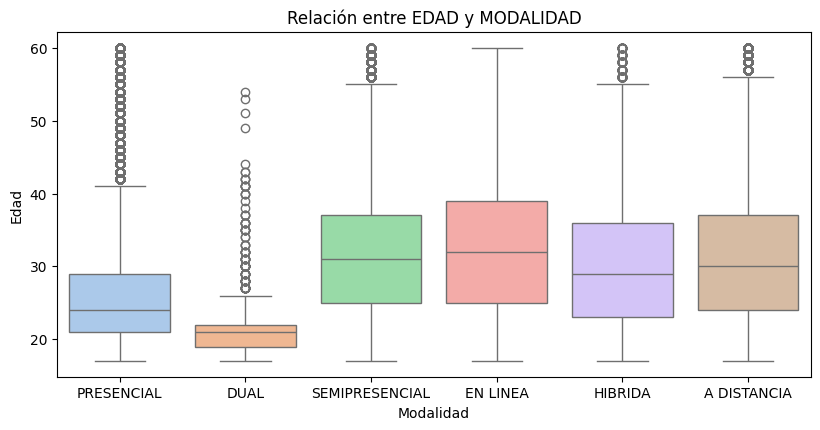

In [ ]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 3)
sns.boxplot(data=df, x='MODALIDAD', y='EDAD', palette='pastel')
plt.title('Relación entre EDAD y MODALIDAD')
plt.xlabel('Modalidad')
plt.ylabel('Edad')
plt.tight_layout()
plt.show()

**2.8 Combinación de variables: 'CAMPO_AMPLIO' vs. 'MODALIDAD'**

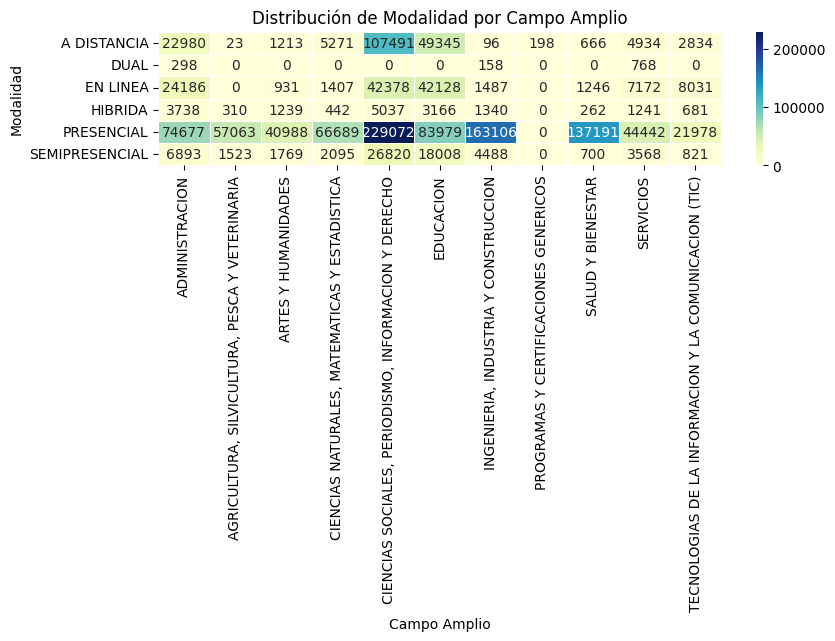

In [ ]:
plt.figure(figsize=(16, 8))
plt.subplot(2, 2, 4)

# Agrupación de los datos y creación de la tabla cruzada
modalidad_campo = df.groupby(['MODALIDAD', 'CAMPO_AMPLIO']).size().unstack().fillna(0)

# Crear el Heatmap con etiquetas
sns.heatmap(modalidad_campo, cmap='YlGnBu', annot=True, fmt='g', cbar=True, linewidths=0.5)

# Títulos y etiquetas
plt.title('Distribución de Modalidad por Campo Amplio')
plt.xlabel('Campo Amplio')
plt.ylabel('Modalidad')

# Ajustar el layout
plt.tight_layout()
plt.show()

**2.9 Relación entre SEXO y MODALIDAD**

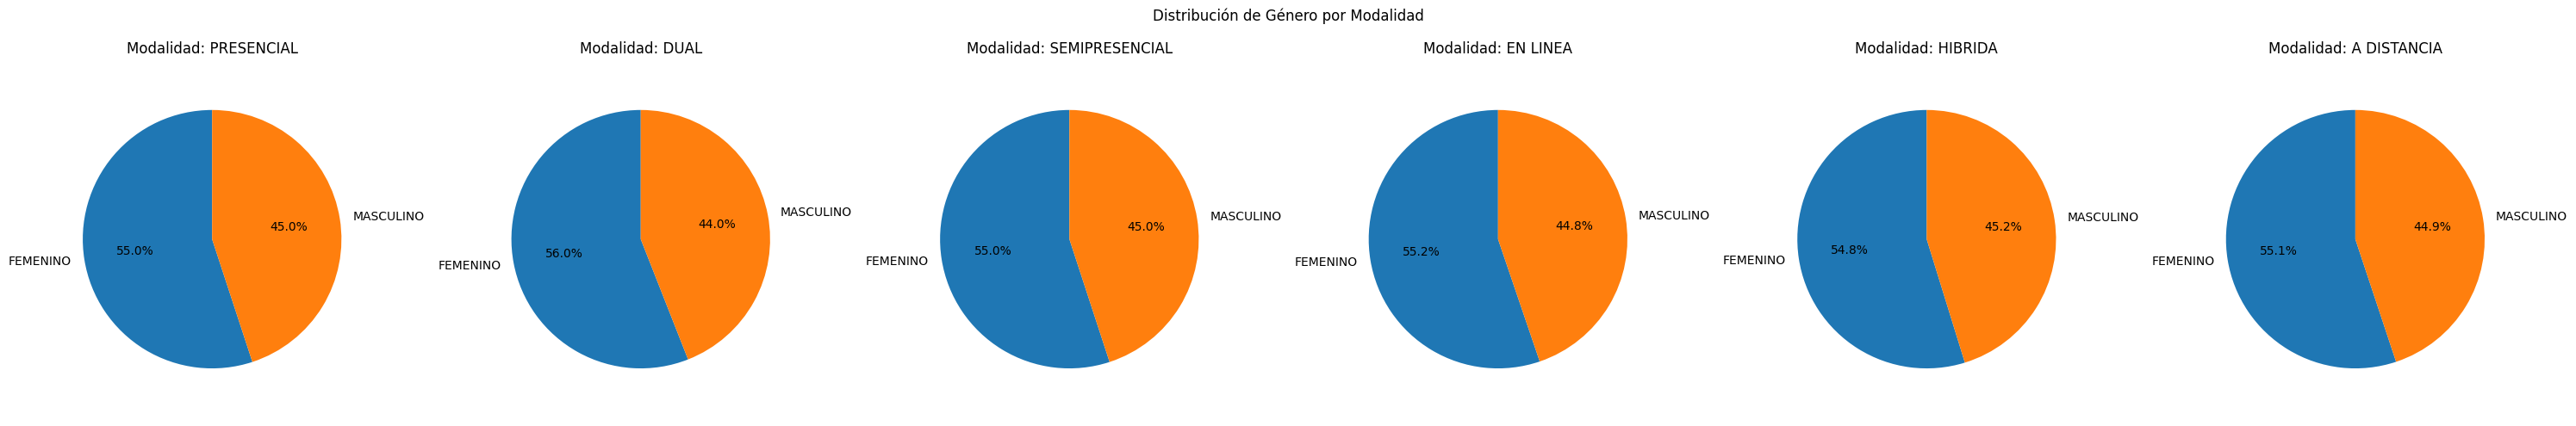

In [ ]:
# Obtener lista de modalidades
modalidad_list = df['MODALIDAD'].unique()

# Definir el número de columnas para los subgráficos (ajusta según el número de modalidades)
ncols = len(modalidad_list)
nrows = 1  # Solo una fila

# Crear los subgráficos
fig, axes = plt.subplots(nrows=1, ncols=ncols, figsize=(ncols * 5, 5))  # Ajustar tamaño según el número de gráficos
fig.suptitle('Distribución de Género por Modalidad')

# Crear gráficos de torta para cada modalidad
for i, modalidad in enumerate(modalidad_list):
    modalidad_data = df[df['MODALIDAD'] == modalidad]
    gender_counts = modalidad_data['SEXO'].value_counts()

    # Usar el eje correspondiente para cada gráfico
    axes[i].pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', startangle=90)
    axes[i].set_title(f'Modalidad: {modalidad}')
    axes[i].axis('equal')  # Para que el gráfico sea circular

# Mostrar los gráficos
plt.tight_layout()
plt.show()

**2.10 Matriz de correlación en variables numéricas**

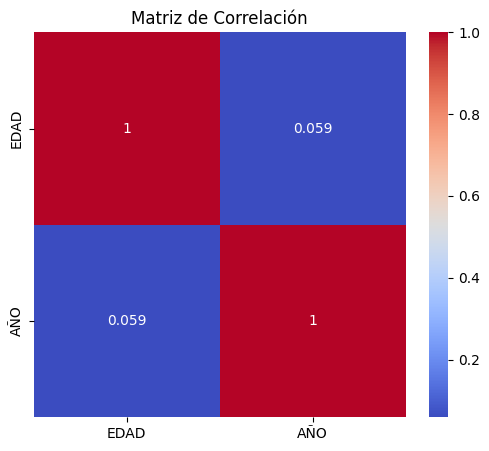

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(df[['EDAD', 'AÑO']].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación')
plt.show()

**2.11 Relación entre Año y Edad**

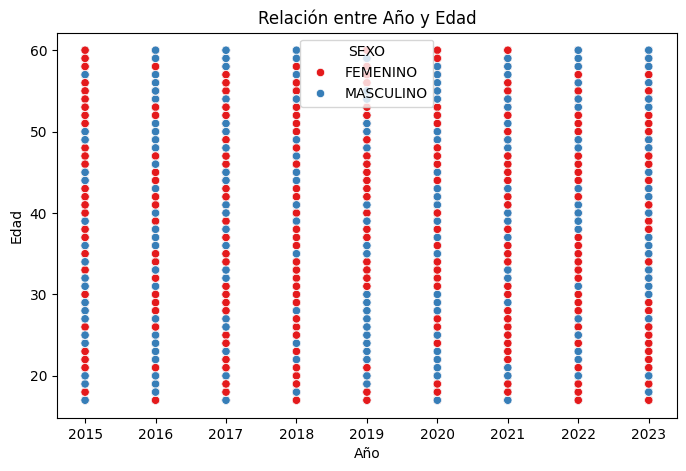

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x='AÑO', y='EDAD', hue='SEXO', data=df, palette='Set1')
plt.title('Relación entre Año y Edad')
plt.xlabel('Año')
plt.ylabel('Edad')
plt.show()

**2.12 Distribución de Edad por Modalidad**

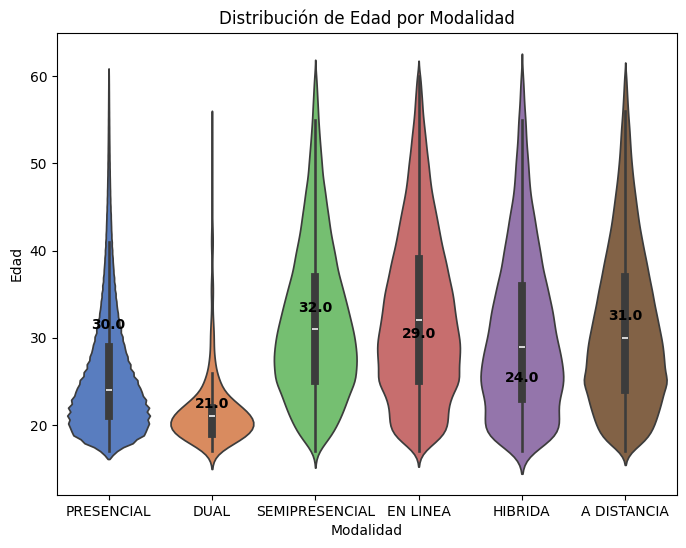

In [ ]:
# Calcular la mediana de EDAD para cada modalidad
medianas = df.groupby('MODALIDAD')['EDAD'].median()

# Crear el Violin Plot
plt.figure(figsize=(8, 6))
sns.violinplot(x='MODALIDAD', y='EDAD', data=df, palette='muted')

# Añadir etiquetas con la mediana
for i, mediana in enumerate(medianas):
    plt.text(i, mediana + 1, f'{mediana:.1f}', horizontalalignment='center',
             size=10, color='black', weight='semibold')

# Configuraciones finales
plt.title('Distribución de Edad por Modalidad')
plt.xlabel('Modalidad')
plt.ylabel('Edad')
plt.show()

# **3. MODELOS DE PREDICCIÓN**

# **3.1 Regresión Logística Binario Preliminar**

**3.1.1 Unión de las variables de Modaliad**

In [ ]:
#Para trabajar con la regresión logística de dos varibales trabajaremos con PRESENCIAL y el resto de modalidades será NO PRESENCIAL
# Crear una nueva columna MODALIDAD_BINARIA
df['MODALIDAD_BINARIA'] = df['MODALIDAD'].apply(lambda x: 1 if x == 'PRESENCIAL' else 0)

# Verificar la distribución de la nueva variable
print(df['MODALIDAD_BINARIA'].value_counts())

MODALIDAD_BINARIA
1    919185
0    409382
Name: count, dtype: int64


**3.1.2 Recodificación de las variables categóticas con Label Encoder**

In [ ]:
var_cuantitativas = df.select_dtypes('number').columns
var_cualitativas  =df.select_dtypes('object').columns

In [ ]:
# creating instance of labelencoder
labelencoder = LabelEncoder()

In [ ]:
df[var_cualitativas] = df[var_cualitativas].apply(labelencoder.fit_transform)

**3.1.3 Separación de la Varibale Objetivo de los Predictores**

In [ ]:
X_logit = df[df.columns.difference(['MODALIDAD_BINARIA','MODALIDAD'])]
y_logit = df.MODALIDAD_BINARIA

**3.1.4 Train / Test Split**

In [ ]:
X_train_logit, X_test_logit, y_train_logit, y_test_logit = train_test_split(X_logit, y_logit, test_size=0.10, random_state=123)

In [ ]:
print("\nColumnas en X_train_logit después de la división:")
print(X_train_logit.columns)


Columnas en X_train_logit después de la división:
Index(['AÑO', 'CAMPO_AMPLIO', 'DISCAPACIDAD', 'EDAD', 'ETNIA', 'NIVEL_FORMACION', 'NOMBRE_CARRERA', 'NOMBRE_IES', 'PROVINCIA_RESIDENCIA', 'SEXO', 'TIPO_FINANCIAMIENTO'], dtype='object')


In [ ]:
print(X_train_logit.shape,"",type(X_train_logit))
print(X_train_logit.shape,"\t ",type(y_train_logit))
print(X_test_logit.shape,"",type(X_test_logit))
print(X_test_logit.shape,"\t ",type(y_test_logit))

(1195710, 11)  <class 'pandas.core.frame.DataFrame'>
(1195710, 11) 	  <class 'pandas.core.series.Series'>
(132857, 11)  <class 'pandas.core.frame.DataFrame'>
(132857, 11) 	  <class 'pandas.core.series.Series'>


**3.1.5 Imputación de los datos**

Este paso fue realizado durante el análsis exploratorio.

**3.1.6 Modelo preliminar de Regresión logística con Sklearn**

***3.1.6.1 Entrenamiento del Modelo***

In [ ]:
modelo_logistico = LogisticRegression()
modelo_logistico.fit(X_train_logit, y_train_logit)

LogisticRegression()

**3.1.6.2 Predicciones**

In [ ]:
predicciones_train_logit = modelo_logistico.predict(X_train_logit)
predicciones_test_logit  = modelo_logistico.predict(X_test_logit)

**3.1.6.3 Métricas de Evaluación**

**3.1.6.3.1 Accuracy**

In [ ]:
accuracy_train1 = round(accuracy_score(y_train_logit, predicciones_train_logit), 2)
accuracy_test1 = round(accuracy_score(y_test_logit, predicciones_test_logit), 2)

print("\nPrecisión en el conjunto de entrenamiento (Modelo 1):", accuracy_train1)
print("Precisión en el conjunto de prueba (Modelo 1):", accuracy_test1)


Precisión en el conjunto de entrenamiento (Modelo 1): 0.77
Precisión en el conjunto de prueba (Modelo 1): 0.77


**3.1.6.2 Matriz de Confusión**

In [ ]:
cm = metrics.confusion_matrix(y_test_logit, predicciones_test_logit)
print("\nMatriz de confusión del Modelo 1:")
print(cm)


Matriz de confusión del Modelo 1:
[[19622 21047]
 [ 9056 83132]]


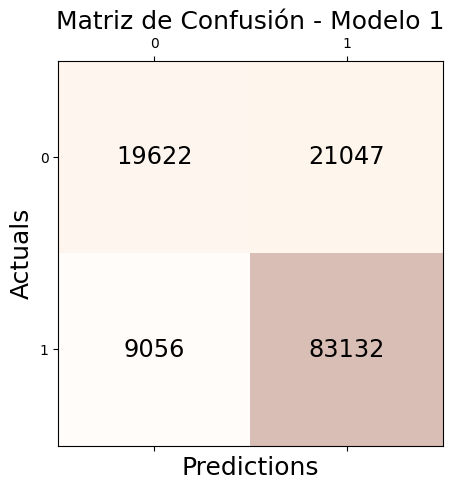

In [ ]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(cm, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(x=j, y=i,s=cm[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predictions', fontsize=18)
plt.ylabel('Actuals', fontsize=18)
plt.title('Matriz de Confusión - Modelo 1', fontsize=18)
plt.show()

**3.1.6.3 Precisión**

In [ ]:
precision1 = round(precision_score(y_test_logit, predicciones_test_logit, pos_label=1), 2)
print("\nPrecisión (Precision) del Modelo 1:", precision1)


Precisión (Precision) del Modelo 1: 0.8


**3.1.6.4 Exhaustividad o "Recall"**

In [ ]:
recall1 = round(recall_score(y_test_logit, predicciones_test_logit, pos_label=1), 2)
print("Sensibilidad (Recall) del Modelo 1:", recall1)

Sensibilidad (Recall) del Modelo 1: 0.9


**3.1.6.5 F1 Score**

In [ ]:
f1_score1 = round(f1_score(y_test_logit, predicciones_test_logit, pos_label=1), 2)
print("Puntaje F1 (F1 Score) del Modelo 1:", f1_score1)

Puntaje F1 (F1 Score) del Modelo 1: 0.85


**3.1.6.4 Importancia de las Variables**

In [ ]:
sc_logit = StandardScaler()

In [ ]:
X_train_std_logit = sc_logit.fit_transform(X_train_logit)
X_test_std_logit = sc_logit.transform(X_test_logit)

**3.1.6.4.1  Entrenar el Modelo con los Datos de Entrenamiento**

In [ ]:
modelo_logistico_std = LogisticRegression()
modelo_logistico_std.fit(X_train_std_logit, y_train_logit)

LogisticRegression()

**3.1.6.4.2 Predicciones**

In [ ]:
predicciones_train_logit_std = modelo_logistico_std.predict(X_train_std_logit)
predicciones_test_logit_std  = modelo_logistico_std.predict(X_test_std_logit)

**3.1.6.4.3 Extracción de los Coeficientes**

In [ ]:
importancia_logit = abs(modelo_logistico_std.coef_[0])

In [ ]:
# Get the names of the features
nombres_variables = X_logit.columns

# Create a dictionary to store the feature importances with their names
importancia_variables = {}
for i, v in enumerate(importancia_logit):
    importancia_variables[nombres_variables[i]] = v

# Sort the feature importances in descending order
importancia_variables_ordenadas = dict(sorted(importancia_variables.items(), key=lambda item: item[1], reverse=True))

# Print the feature importances with their names
for nombre, importancia in importancia_variables_ordenadas.items():
    print('Variable explicativa: %s, Score: %.5f' % (nombre, importancia))

Variable explicativa: NOMBRE_IES, Score: 0.77689
Variable explicativa: EDAD, Score: 0.75416
Variable explicativa: TIPO_FINANCIAMIENTO, Score: 0.41156
Variable explicativa: AÑO, Score: 0.31001
Variable explicativa: CAMPO_AMPLIO, Score: 0.16885
Variable explicativa: NOMBRE_CARRERA, Score: 0.12673
Variable explicativa: ETNIA, Score: 0.07315
Variable explicativa: NIVEL_FORMACION, Score: 0.03467
Variable explicativa: PROVINCIA_RESIDENCIA, Score: 0.01956
Variable explicativa: SEXO, Score: 0.00187
Variable explicativa: DISCAPACIDAD, Score: 0.00107


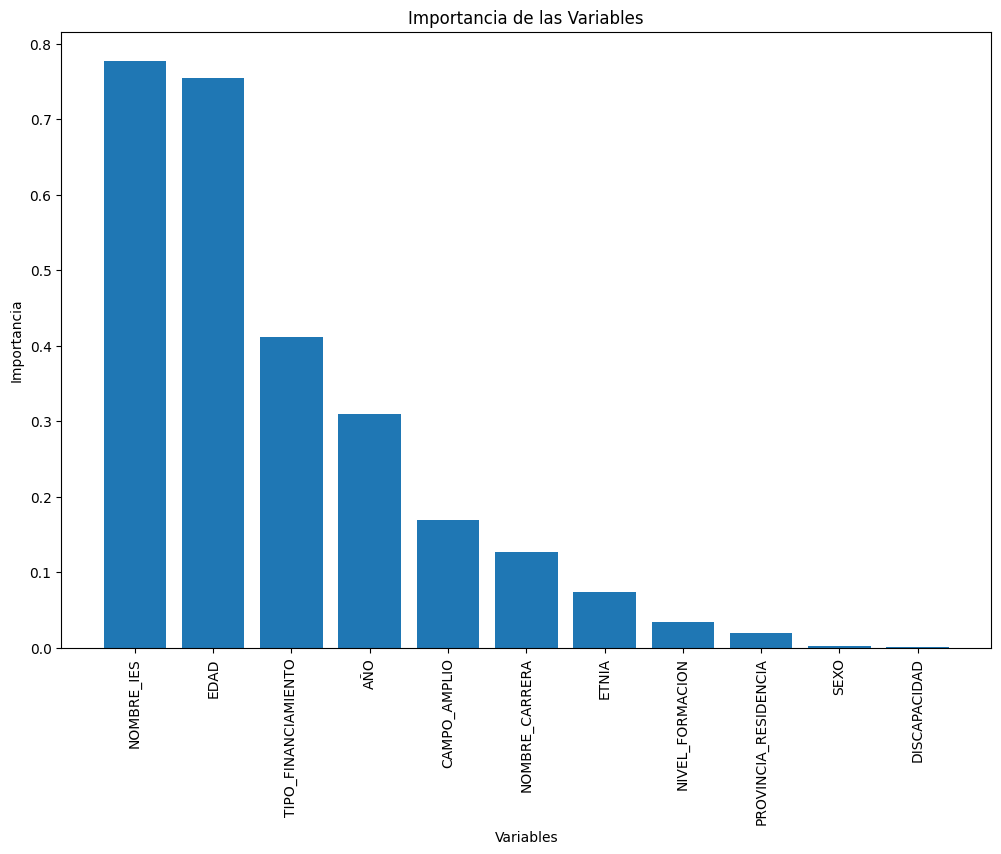

In [ ]:
# Ordenar las importancias de mayor a menor junto con los nombres de las variables
importancia_ordenada, nombres_ordenados = zip(*sorted(zip(importancia_logit, nombres_variables), reverse=True))

# Graficar la importancia de las variables
plt.figure(figsize=(12, 8))
plt.bar(range(len(importancia_ordenada)), importancia_ordenada)
plt.xticks(range(len(nombres_ordenados)), nombres_ordenados, rotation=90)
plt.xlabel('Variables')
plt.ylabel('Importancia')
plt.title('Importancia de las Variables')
plt.show()

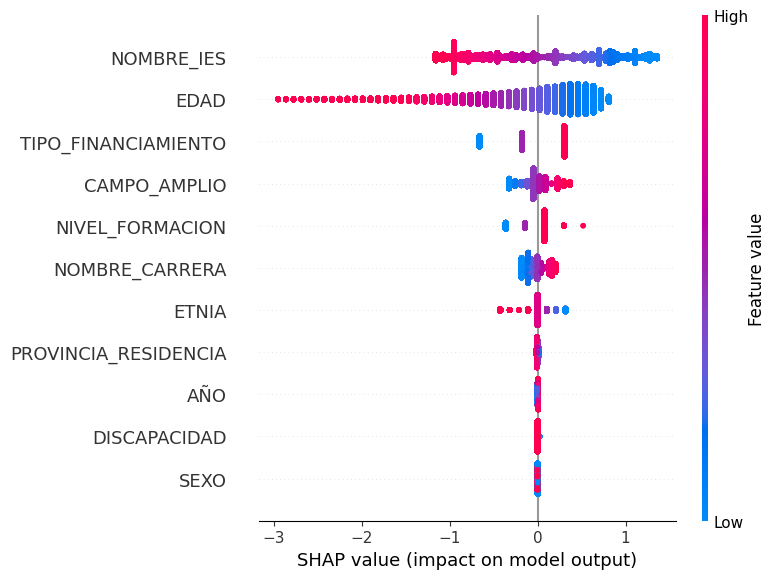

In [ ]:
# Usar SHAP para explicar la importancia de las variables
explainer = shap.Explainer(modelo_logistico, X_train_logit)
shap_values = explainer(X_test_logit)

# Graficar la importancia de las variables con SHAP
shap.summary_plot(shap_values, X_test_logit)

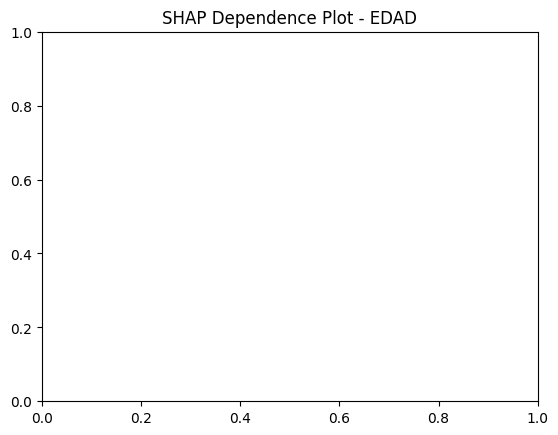

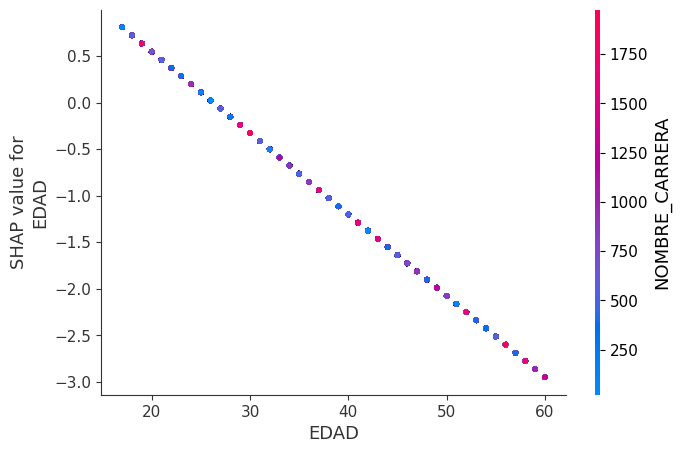

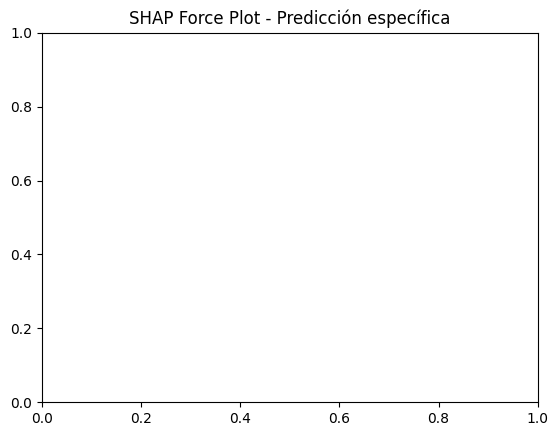

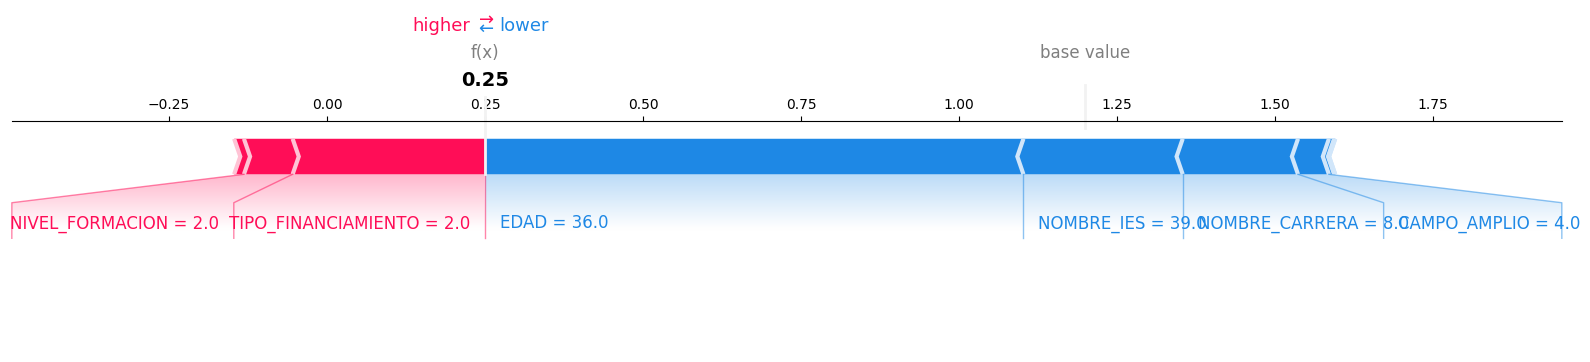

In [ ]:
# Inicializar el explainer de SHAP con el modelo entrenado
explainer = shap.Explainer(modelo_logistico, X_train_logit)

# Obtener los valores SHAP para el conjunto de prueba
shap_values = explainer(X_test_logit)

# Gráfico de Dependencia para la variable EDAD
plt.title("SHAP Dependence Plot - EDAD")
shap.dependence_plot("EDAD", shap_values.values, X_test_logit, feature_names=X_test_logit.columns)

# Visualización detallada para una predicción específica (opcional)
# Seleccionar un índice del conjunto de prueba
indice_prediccion = 10

# Gráfico Force Plot para una predicción específica
plt.title("SHAP Force Plot - Predicción específica")
shap.force_plot(explainer.expected_value, shap_values[indice_prediccion].values, X_test_logit.iloc[indice_prediccion], matplotlib=True)

# Mostrar todos los gráficos generados
plt.show()

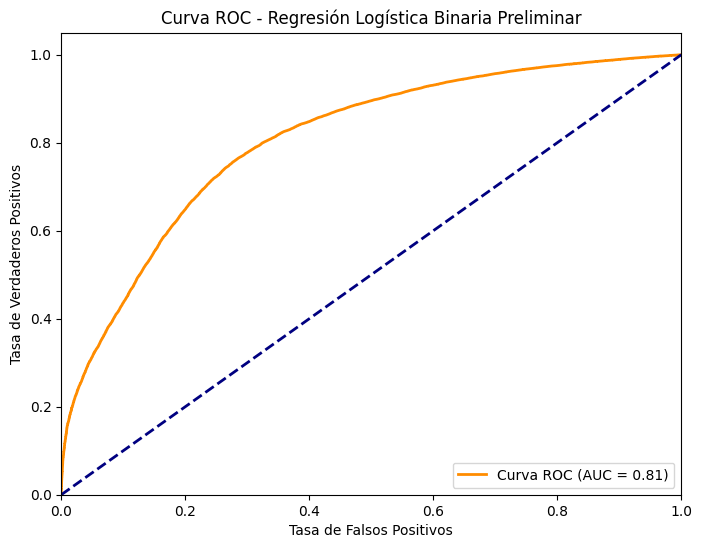

In [ ]:
# prompt: grafica la curva ROC AUC del  modelo Regresión Logística Binario Preliminar

# Obtener las probabilidades predichas para la clase positiva (1)
y_pred_proba = modelo_logistico.predict_proba(X_test_logit)[:, 1]

# Calcular la curva ROC y el AUC
fpr, tpr, thresholds = roc_curve(y_test_logit, y_pred_proba)
roc_auc = roc_auc_score(y_test_logit, y_pred_proba)

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='Curva ROC (AUC = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Regresión Logística Binaria Preliminar')
plt.legend(loc="lower right")
plt.show()

La variable NOMBRE_CARRERA es la más influyente en la predicción de la modalidad de estudio.

Las carreras específicas parecen tener un impacto significativo en la elección de modalidad.

Carreras técnicas o presenciales tienden a favorecer la modalidad presencial, mientras que carreras más teóricas pueden inclinarse hacia modalidades a distancia o en línea.

La variable EDAD también tiene un gran impacto.

Valores altos de edad (en rojo) tienden a correlacionarse con modalidades no presenciales (como A DISTANCIA o EN LÍNEA).

Estudiantes más jóvenes parecen preferir la modalidad presencial.

NOMBRE_IES (nombre de la institución educativa) es otra variable relevante.

Algunas instituciones pueden ofrecer más opciones en línea o híbridas, lo que impacta la modalidad elegida.

# **3.2 Modelo de Regresión Logística Definitivo - Eliminando las variables Poco Significativas**

In [ ]:
X_logit2 = df[df.columns.difference(['MODALIDAD_BINARIA', 'MODALIDAD', 'PROVINCIA_RESIDENCIA', 'SEXO', 'DISCAPACIDAD', 'NOMBRE_CARRERA', 'ETNIA', 'AÑO'])]
y_logit2 = df.MODALIDAD_BINARIA

In [ ]:
X_train_logit2, X_test_logit2, y_train_logit2, y_test_logit2 = train_test_split(
    X_logit2, y_logit2, test_size=0.10, random_state=123, stratify=y_logit2
)

**3.2.1 Entrenamiento del Modelo Definitivo**

In [ ]:
modelo_logistico2 = LogisticRegression()
modelo_logistico2.fit(X_train_logit2, y_train_logit2)

LogisticRegression()

**3.2.2 Preducciones Modelo Definitivo**

In [ ]:
predicciones_train_logit2 = modelo_logistico2.predict(X_train_logit2)
predicciones_test_logit2 = modelo_logistico2.predict(X_test_logit2)

**3.2.3 Métricas Modelo Definitivo**

**3.2.3.1 Accuracy**

In [ ]:
accuracy_train2 = round(accuracy_score(y_train_logit2, predicciones_train_logit2), 2)
accuracy_test2 = round(accuracy_score(y_test_logit2, predicciones_test_logit2), 2)

print("\nPrecisión en el conjunto de entrenamiento (Modelo 2):", accuracy_train2)
print("Precisión en el conjunto de prueba (Modelo 2):", accuracy_test2)


Precisión en el conjunto de entrenamiento (Modelo 2): 0.77
Precisión en el conjunto de prueba (Modelo 2): 0.77


**3.2.3.2 Matriz de Confusión**

In [ ]:
# Calcular la matriz de confusión
cm2 = metrics.confusion_matrix(y_test_logit2, predicciones_test_logit2)
print("\nMatriz de confusión del Modelo 2:")
print(cm2)


Matriz de confusión del Modelo 2:
[[19501 21437]
 [ 8959 82960]]


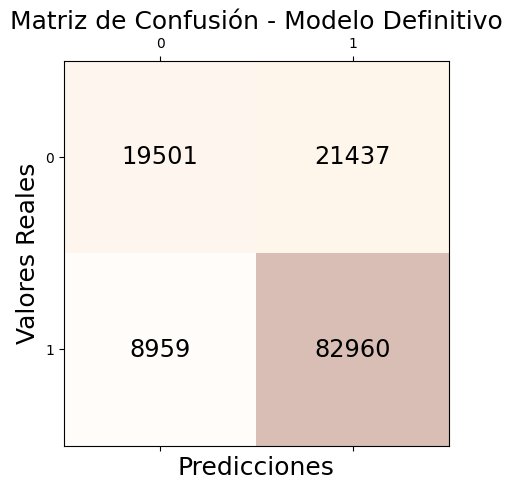

In [ ]:
# Visualizar la matriz de confusión
fig, ax = plt.subplots(figsize=(5, 5))
ax.matshow(cm2, cmap=plt.cm.Oranges, alpha=0.3)
for i in range(cm2.shape[0]):
    for j in range(cm2.shape[1]):
        ax.text(x=j, y=i, s=cm2[i, j], va='center', ha='center', size='xx-large')

plt.xlabel('Predicciones', fontsize=18)
plt.ylabel('Valores Reales', fontsize=18)
plt.title('Matriz de Confusión - Modelo Definitivo', fontsize=18)
plt.show()

**3.2.3.3 Precisión**

In [ ]:
precision2 = round(precision_score(y_test_logit2, predicciones_test_logit2, pos_label=1), 2)
print("\nPrecisión (Precision) del Modelo 2:", precision2)


Precisión (Precision) del Modelo 2: 0.79


**3.2.3.4 Exhaustividad o "Recall"**

In [ ]:
recall2 = round(recall_score(y_test_logit2, predicciones_test_logit2, pos_label=1), 2)
print("Sensibilidad (Recall) del Modelo 2:", recall2)

Sensibilidad (Recall) del Modelo 2: 0.9


**3.2.3.5 F1 Score**

In [ ]:
f1_score2 = round(f1_score(y_test_logit2, predicciones_test_logit2, pos_label=1), 2)
print("Puntaje F1 (F1 Score) del Modelo 2:", f1_score2)

Puntaje F1 (F1 Score) del Modelo 2: 0.85


**3.2.4 Importancia de las Variables**

In [ ]:
importancia_logit2 = abs(modelo_logistico2.coef_[0])

In [ ]:
# Resumen
for i,v in enumerate(importancia_logit2):
    print('Variable explicativa No. %0d, Score: %.5f' % (i,v))

Variable explicativa No. 0, Score: 0.08456
Variable explicativa No. 1, Score: 0.08876
Variable explicativa No. 2, Score: 0.19976
Variable explicativa No. 3, Score: 0.04037
Variable explicativa No. 4, Score: 0.51497


In [ ]:
# Get the names of the features
nombres_variables = X_logit2.columns

# Create a dictionary to store the feature importances with their names
importancia_variables = {}
for i in range(min(len(importancia_logit2), len(nombres_variables))):
    importancia_variables[nombres_variables[i]] = importancia_logit2[i]

# Sort the feature importances in descending order
importancia_variables_ordenadas = dict(sorted(importancia_variables.items(), key=lambda item: item[1], reverse=True))

# Print the feature importances with their names
for nombre, importancia in importancia_variables_ordenadas.items():
    print('Variable explicativa: %s, Score: %.5f' % (nombre, importancia))


Variable explicativa: TIPO_FINANCIAMIENTO, Score: 0.51497
Variable explicativa: NIVEL_FORMACION, Score: 0.19976
Variable explicativa: EDAD, Score: 0.08876
Variable explicativa: CAMPO_AMPLIO, Score: 0.08456
Variable explicativa: NOMBRE_IES, Score: 0.04037


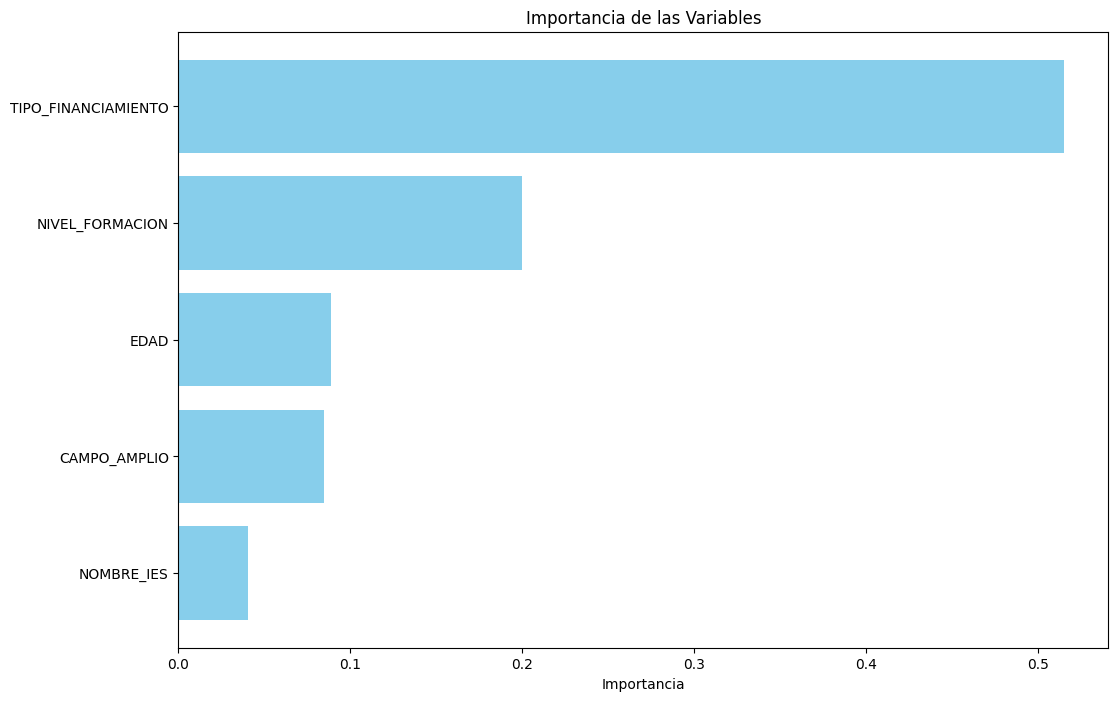

In [ ]:
# Obtener los nombres de las variables y las importancias ordenadas de mayor a menor
nombres_variables_ordenadas = list(importancia_variables_ordenadas.keys())
importancia_valores_ordenados = list(importancia_variables_ordenadas.values())

# Graficar la importancia de las variables
plt.figure(figsize=(12, 8))
plt.barh(nombres_variables_ordenadas, importancia_valores_ordenados, color='skyblue')
plt.xlabel('Importancia')
plt.title('Importancia de las Variables')
plt.gca().invert_yaxis()  # Invertir el eje Y para mostrar las barras de mayor a menor
plt.show()

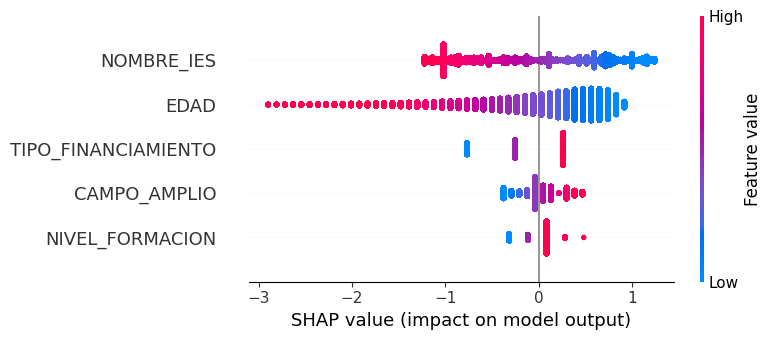

In [ ]:
# Usar SHAP para explicar la importancia de las variables
explainer = shap.Explainer(modelo_logistico2, X_train_logit2)
shap_values = explainer(X_test_logit2)

# Graficar la importancia de las variables con SHAP
shap.summary_plot(shap_values, X_test_logit2)

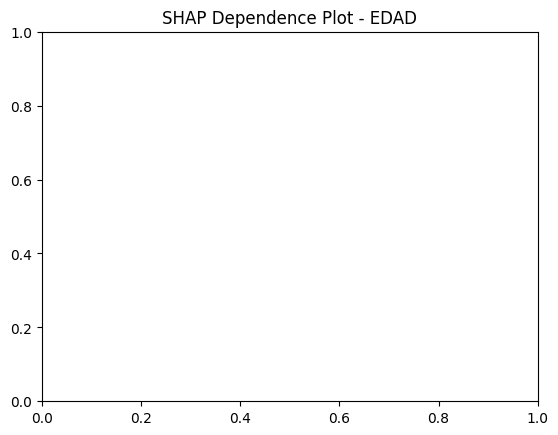

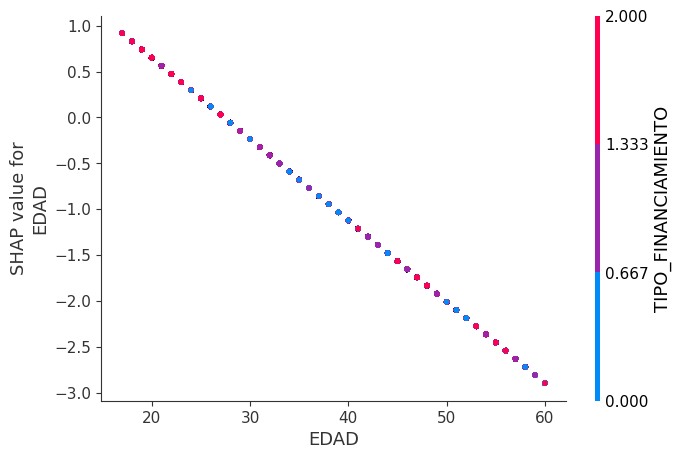

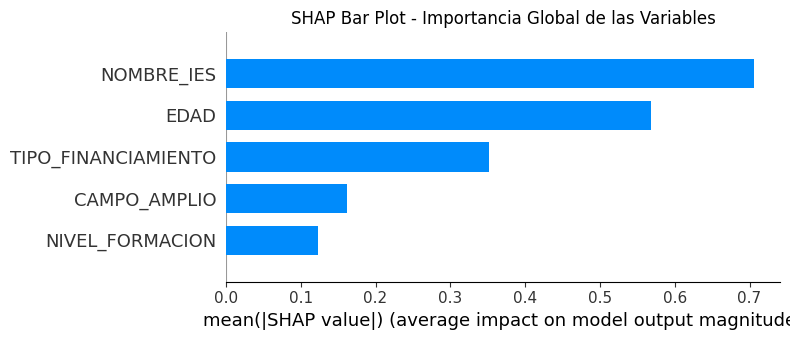

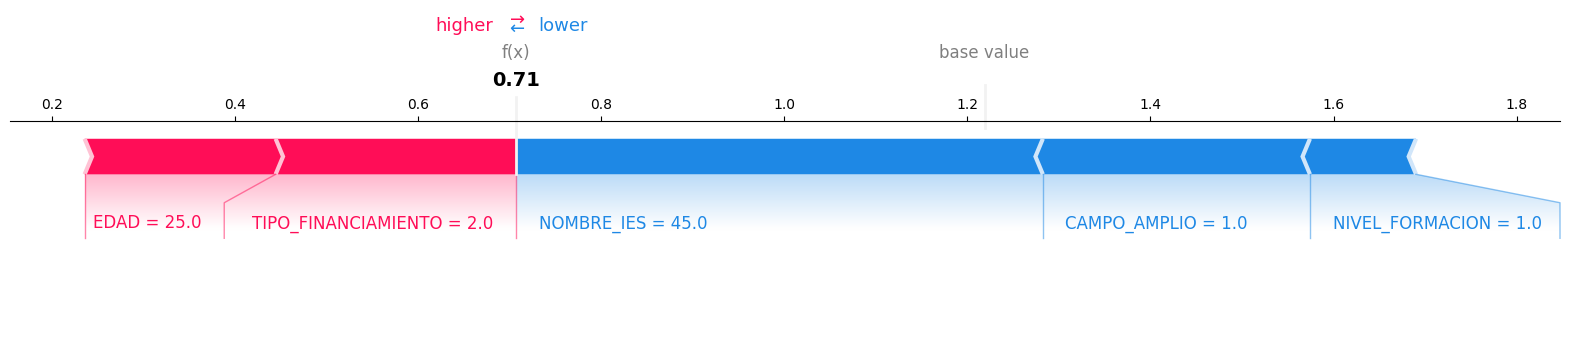

In [ ]:
# Inicializar el explainer de SHAP con el modelo ajustado y los datos de entrenamiento correctos
explainer_definitivo = shap.Explainer(modelo_logistico2, X_train_logit2)  # Cambiado a X_train_logit2

# Obtener los valores SHAP para el conjunto de prueba, usando los datos de prueba correctos
shap_values_definitivo = explainer_definitivo(X_test_logit2)  # Cambiado a X_test_logit2

# 2. Gráfico de Dependencia para la variable EDAD
plt.title("SHAP Dependence Plot - EDAD")
shap.dependence_plot("EDAD", shap_values_definitivo.values, X_test_logit2, feature_names=X_test_logit2.columns) # Cambiado a X_test_logit2

# 3. Gráfico de Barras (Bar Plot) para mostrar la importancia global de las variables
plt.title("SHAP Bar Plot - Importancia Global de las Variables")
shap.summary_plot(shap_values_definitivo, X_test_logit2, plot_type="bar") # Cambiado a X_test_logit2

# 4. Visualización detallada para una predicción específica (opcional)
indice_prediccion = 20  # Cambia este índice para ver diferentes predicciones

# Gráfico Force Plot para una predicción específica
shap.force_plot(explainer_definitivo.expected_value, shap_values_definitivo[indice_prediccion].values, X_test_logit2.iloc[indice_prediccion], matplotlib=True) # Cambiado a X_test_logit2

# Mostrar los gráficos
plt.show()

NOMBRE_IES: El gráfico muestra que el impacto del nombre de la institución varía dependiendo de las opciones de modalidad que ofrece cada institución.

Algunas instituciones parecen tener un fuerte sesgo hacia modalidades presenciales, mientras que otras favorecen modalidades en línea.

EDAD: Los estudiantes más jóvenes tienen un valor SHAP positivo, lo que sugiere que prefieren modalidades presenciales.

A medida que la edad aumenta, el valor SHAP disminuye, indicando una mayor preferencia por modalidades no presenciales.

TIPO_FINANCIAMIENTO: La modalidad de financiamiento también afecta la modalidad elegida.

Los estudiantes con financiamiento público pueden inclinarse hacia modalidades presenciales, mientras que los estudiantes con financiamiento privado pueden tener más flexibilidad para optar por modalidades a distancia.

CAMPO_AMPLIO y NIVEL_FORMACION también tienen un impacto, aunque menor.

**3.2.5 Curva ROC del Modelo Definitivo**

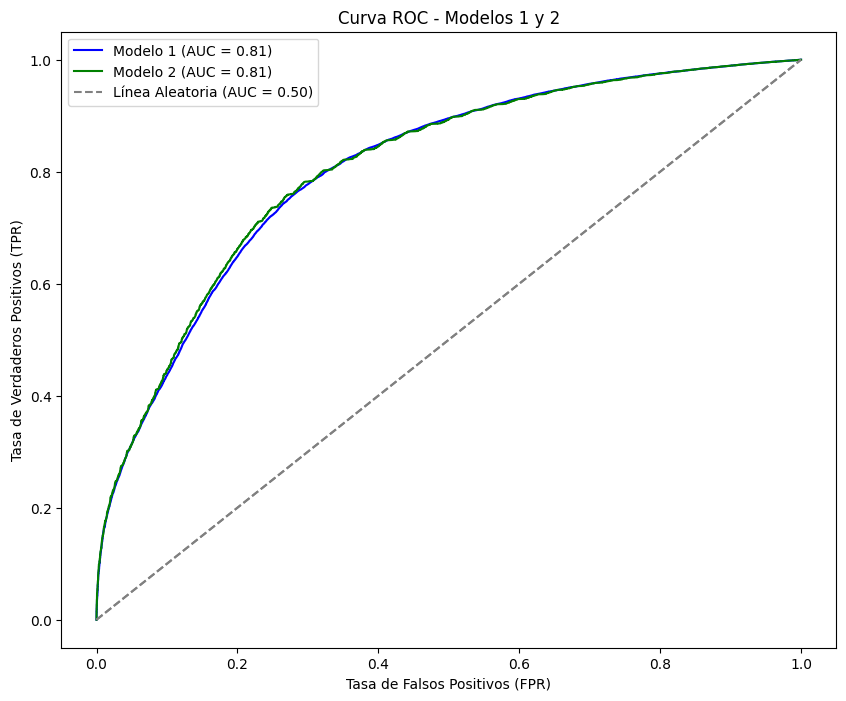

In [ ]:
# Calcular probabilidades de predicción para el Modelo 1
probas_modelo1 = modelo_logistico.predict_proba(X_test_logit)[:, 1]

# Calcular probabilidades de predicción para el Modelo 2
probas_modelo2 = modelo_logistico2.predict_proba(X_test_logit2)[:, 1]

# Calcular la curva ROC y AUC para el Modelo 1
fpr1, tpr1, _ = roc_curve(y_test_logit, probas_modelo1)
auc1 = roc_auc_score(y_test_logit, probas_modelo1)

# Calcular la curva ROC y AUC para el Modelo 2
fpr2, tpr2, _ = roc_curve(y_test_logit2, probas_modelo2)
auc2 = roc_auc_score(y_test_logit2, probas_modelo2)

# Graficar las curvas ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr1, tpr1, label=f'Modelo 1 (AUC = {auc1:.2f})', color='blue')
plt.plot(fpr2, tpr2, label=f'Modelo 2 (AUC = {auc2:.2f})', color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Línea Aleatoria (AUC = 0.50)')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC - Modelos 1 y 2')
plt.legend()
plt.show()


Presenta un AUC = 0.81, lo cual indica que el modelo de regresión logística tiene un buen desempeño en la discriminación entre clases.

AUC = 0.5: El modelo no es mejor que una clasificación aleatoria (línea diagonal).

0.7 ≤ AUC < 0.8: Modelo aceptable.

0.8 ≤ AUC < 0.9: Modelo bueno.

0.9 ≤ AUC < 1.0: Modelo muy bueno o excelente.

Con AUC = 0.81, el modelo es bueno y tiene una alta capacidad para distinguir entre las clases positivas y negativas.

# **3.3 Regresión Logística enfoque econométrico**

In [ ]:
# Seleccionar las variables explicativas relevantes de acuerdo a lo estudiando en el modelo previo
variables_explicativas = ['EDAD', 'TIPO_FINANCIAMIENTO', 'NIVEL_FORMACION', 'CAMPO_AMPLIO', 'NOMBRE_IES','SEXO']

In [ ]:
#Preparar los datos para statsmodels
X = df[variables_explicativas]
X = sm.add_constant(X)  # Agregar una constante para la intersección
y = df['MODALIDAD_BINARIA']

In [ ]:
#Ajustar el modelo de regresión logística
modelo = sm.Logit(y, X).fit()

Optimization terminated successfully.
         Current function value: 0.483411
         Iterations 6


**3.3.1 Interpretación de los coeficentes**

In [ ]:
# Mostrar los coeficientes y sus odds ratios
coeficientes = modelo.params
odds_ratios = coeficientes.apply(lambda x: np.exp(x))

print("Coeficientes del modelo:")
print(coeficientes)
print("\nOdds Ratios:")
print(odds_ratios)

Coeficientes del modelo:
const                  3.43
EDAD                  -0.09
TIPO_FINANCIAMIENTO    0.52
NIVEL_FORMACION        0.20
CAMPO_AMPLIO           0.08
NOMBRE_IES            -0.04
SEXO                  -0.00
dtype: float64

Odds Ratios:
const                 31.01
EDAD                   0.91
TIPO_FINANCIAMIENTO    1.67
NIVEL_FORMACION        1.22
CAMPO_AMPLIO           1.09
NOMBRE_IES             0.96
SEXO                   1.00
dtype: float64


**3.3.2 Prueba de significancia individual (p-valores)**

In [ ]:
print(modelo.summary())

                           Logit Regression Results                           
Dep. Variable:      MODALIDAD_BINARIA   No. Observations:              1328567
Model:                          Logit   Df Residuals:                  1328560
Method:                           MLE   Df Model:                            6
Date:                Tue, 21 Jan 2025   Pseudo R-squ.:                  0.2173
Time:                        16:04:16   Log-Likelihood:            -6.4224e+05
converged:                       True   LL-Null:                   -8.2053e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                   3.4344      0.013    266.996      0.000       3.409       3.460
EDAD                   -0.0889      0.000   -314.226      0.000      -0.089      -0.088
TIPO_FINANCIAMIE

**3.3.3 Prueba de significancia global (Likelihood Ratio Test)**

In [ ]:
# Prueba de significancia global
from scipy import stats

lr_test = modelo.llr_pvalue
print(f"\nLikelihood Ratio Test p-value: {lr_test:.5f}")


Likelihood Ratio Test p-value: 0.00000


**3.3.4 Evaluar el R² de McFadden**

In [ ]:
mcfadden_r2 = 1 - (modelo.llf / modelo.llnull)
print(f"\nMcFadden R²: {mcfadden_r2:.4f}")


McFadden R²: 0.2173


**3.3.5 Revisar la multicolinealidad (VIF)**

In [ ]:
vif_data = pd.DataFrame()
vif_data["Variable"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print("\nMulticolinealidad (VIF):")
print(vif_data)


Multicolinealidad (VIF):
              Variable   VIF
0                const 35.16
1                 EDAD  1.15
2  TIPO_FINANCIAMIENTO  1.10
3      NIVEL_FORMACION  1.18
4         CAMPO_AMPLIO  1.01
5           NOMBRE_IES  1.10
6                 SEXO  1.00


**3.3.6 Prueba de bondad de ajuste (Hosmer-Lemeshow)**

In [ ]:
hl_test = proportions_chisquare(modelo.llr, [modelo.nobs])
print("\nHosmer-Lemeshow Test:")
print(hl_test)


Hosmer-Lemeshow Test:
(0.0, nan, (array([[356565.37347871, 972001.62652129]]), array([[356565.37347871, 972001.62652129]])))


**3.3.7 Calcular la matriz de confusión y métricas de precisión**

In [ ]:
# Predicciones
y_pred = modelo.predict(X) > 0.5

# Matriz de confusión
cm = confusion_matrix(y, y_pred)
print("\nMatriz de Confusión:")
print(cm)

# Reporte de clasificación
print("\nReporte de Clasificación:")
print(classification_report(y, y_pred))


Matriz de Confusión:
[[195403 213979]
 [ 90437 828748]]

Reporte de Clasificación:
              precision    recall  f1-score   support

           0       0.68      0.48      0.56    409382
           1       0.79      0.90      0.84    919185

    accuracy                           0.77   1328567
   macro avg       0.74      0.69      0.70   1328567
weighted avg       0.76      0.77      0.76   1328567



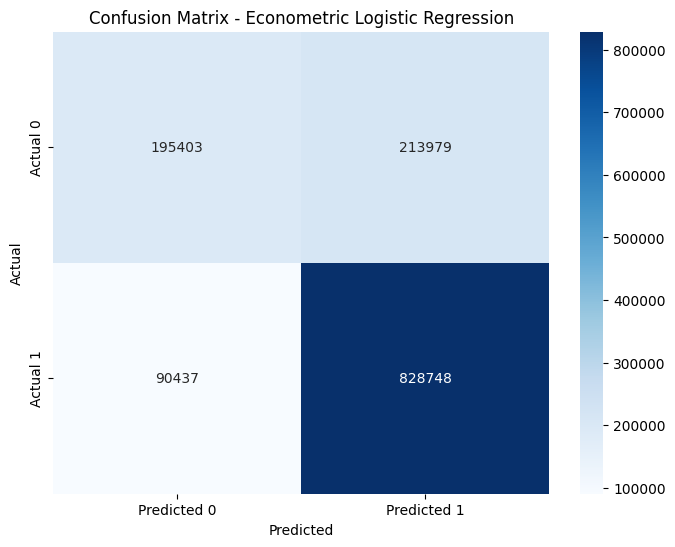

In [ ]:
# prompt: grafica la matriz de confusión del 3.3 Regresión Logística enfoque econométrico

# Assuming 'y' and 'y_pred' are defined from the previous code
# Example:
# y = df['MODALIDAD_BINARIA']
# y_pred = modelo.predict(X) > 0.5

cm = confusion_matrix(y, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Econometric Logistic Regression')
plt.show()

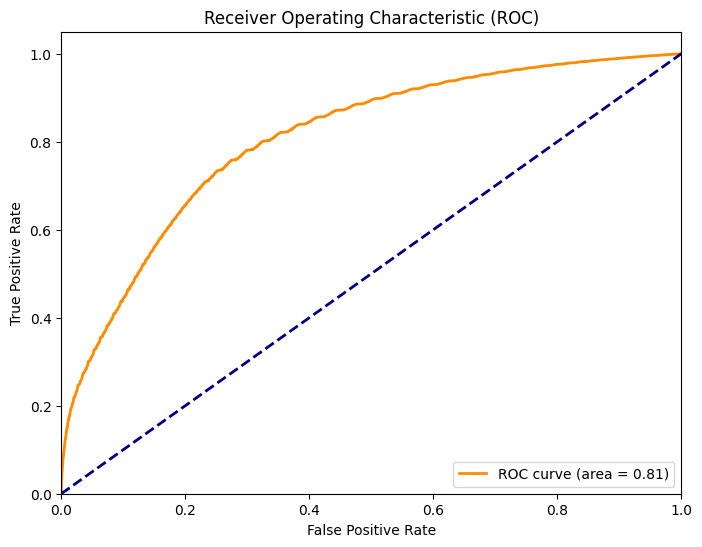

ROC AUC score: 0.81


In [ ]:
# prompt: dame la curva ROC AUC para el modelo 3.3 Regresión Logística enfoque econométrico
# Predict probabilities for the positive class (MODALIDAD_BINARIA = 1)
y_pred_prob = modelo.predict(X)

# Calculate the ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y, y_pred_prob)
roc_auc = roc_auc_score(y, y_pred_prob)


# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

print(f"ROC AUC score: {roc_auc:.2f}")

# **3.4 Random Forest Preliminar**

Ya que todo el dataframe fue codificado por LabelEncoder en el Modelo de Regresión Logística Binario, vamos a revisar como está la codificación de las variables

**3.4.1 Verificación de las variables disponibles para el modelo**

In [ ]:
# Verificar las columnas disponibles
print("\nColumnas disponibles en el DataFrame:")
print(df.columns)


Columnas disponibles en el DataFrame:
Index(['AÑO', 'NOMBRE_IES', 'TIPO_FINANCIAMIENTO', 'NOMBRE_CARRERA', 'NIVEL_FORMACION', 'MODALIDAD', 'PROVINCIA_RESIDENCIA', 'ETNIA', 'DISCAPACIDAD', 'CAMPO_AMPLIO', 'SEXO', 'EDAD', 'MODALIDAD_BINARIA'], dtype='object')


In [ ]:
# Crear un mapeo manual de los nombres de las modalidades
nombres_modalidades = {
    0: 'A DISTANCIA',
    1: 'DUAL',
    2: 'EN LINEA',
    3: 'HIBRIDA',
    4: 'PRESENCIAL',
    5: 'SEMIPRESENCIAL'
}

In [ ]:
# Convertir MODALIDAD a etiquetas numéricas usando el mapeo manual
df['MODALIDAD_LABEL'] = df['MODALIDAD'].map(nombres_modalidades)

In [ ]:
print("\nValores únicos en la columna MODALIDAD_LABEL:")
print(df['MODALIDAD_LABEL'].unique())


Valores únicos en la columna MODALIDAD_LABEL:
['PRESENCIAL' 'DUAL' 'SEMIPRESENCIAL' 'EN LINEA' 'HIBRIDA' 'A DISTANCIA']


In [ ]:
# Verificar la distribución de la nueva variable
print(df['MODALIDAD_LABEL'].value_counts())

MODALIDAD_LABEL
PRESENCIAL        919185
A DISTANCIA       195051
EN LINEA          128966
SEMIPRESENCIAL     66685
HIBRIDA            17456
DUAL                1224
Name: count, dtype: int64


**3.4.2 Definición de las variables predictorias y objetivo**

In [ ]:
# Definir las variables predictoras y la variable objetivo
X = df.drop(columns=['MODALIDAD', 'MODALIDAD_LABEL','MODALIDAD_BINARIA']).select_dtypes(include=['number'])
y = df['MODALIDAD_LABEL']

In [ ]:
# Verificar si hay valores faltantes en MODALIDAD_LABEL
print("\nValores faltantes en MODALIDAD_LABEL:")
print(df['MODALIDAD_LABEL'].isna().sum())


Valores faltantes en MODALIDAD_LABEL:
0


**3.4.3 División de datos en entrenamiento y prueba**

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

**3.4.4 Entreamiento del modelo**

In [ ]:
# Entrenar el modelo Random Forest
rf_model = RandomForestClassifier(random_state=123, n_estimators=100)
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=123)

**3.4.5 Predicciones del modelo**

In [ ]:
# Realizar predicciones
y_pred = rf_model.predict(X_test)

In [ ]:
# Convertir las predicciones y los valores reales a los nombres originales
inverse_nombres_modalidades = {v: k for k, v in nombres_modalidades.items()}
y_pred_labels = [inverse_nombres_modalidades[label] for label in y_pred]
y_test_labels = [inverse_nombres_modalidades[label] for label in y_test]

**3.4.6 Reporte de Clasificación**

In [ ]:
# Generar el reporte de clasificación
target_names = list(nombres_modalidades.values())
print("\nReporte de Clasificación:")
print(classification_report(y_test_labels, y_pred_labels, target_names=target_names))


Reporte de Clasificación:
                precision    recall  f1-score   support

   A DISTANCIA       0.92      0.92      0.92     39010
          DUAL       0.86      0.79      0.83       245
      EN LINEA       0.87      0.88      0.87     25793
       HIBRIDA       0.76      0.72      0.74      3491
    PRESENCIAL       0.96      0.96      0.96    183838
SEMIPRESENCIAL       0.79      0.76      0.78     13337

      accuracy                           0.93    265714
     macro avg       0.86      0.84      0.85    265714
  weighted avg       0.93      0.93      0.93    265714



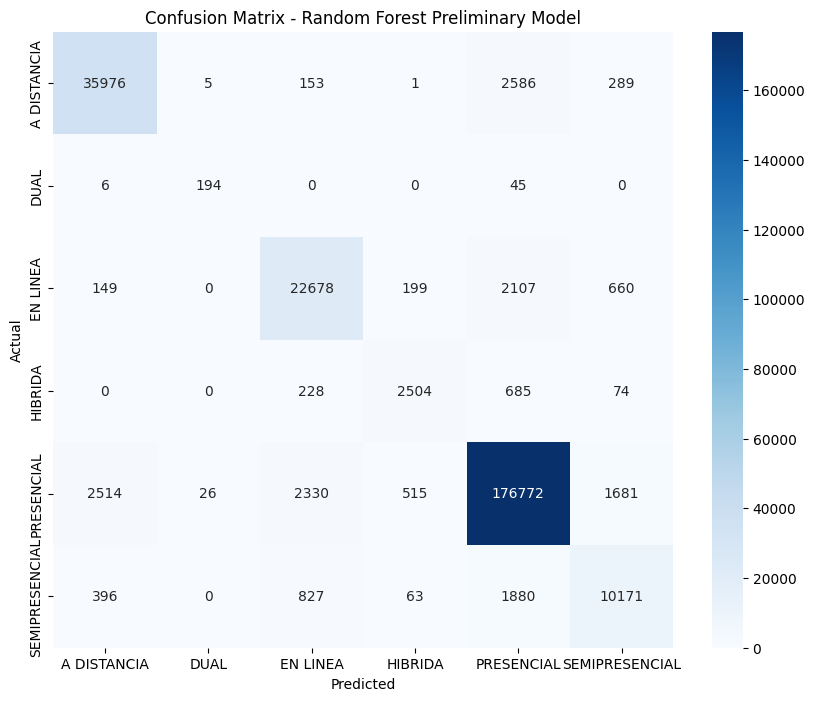

In [ ]:
# prompt: Imprime la matriz de confusión del modelo Random Fores Preliminar

# Assuming 'y_test' and 'y_pred' are defined from your RandomForestClassifier
# Example:
# y_pred = rf_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(nombres_modalidades.values()),
            yticklabels=list(nombres_modalidades.values()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Preliminary Model')
plt.show()

**3.4.7 Importancia de las Variables**

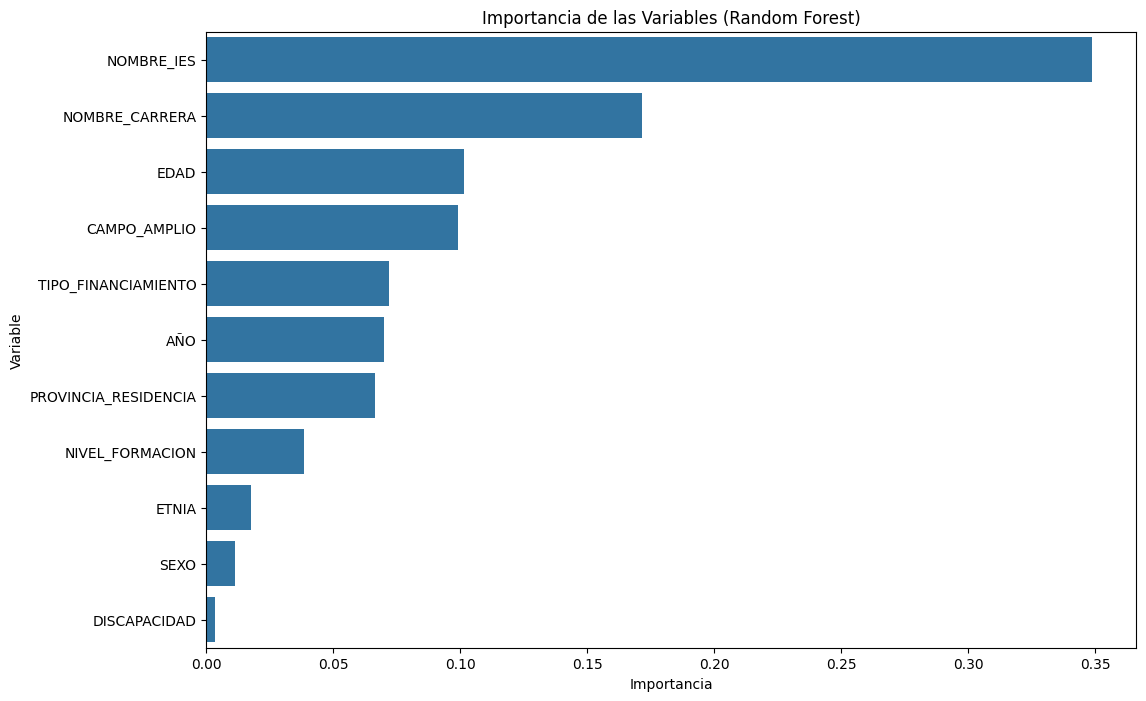

In [ ]:
# Obtener la importancia de las características del modelo Random Forest
importancia_variables = rf_model.feature_importances_

# Obtener los nombres de las características
nombres_variables = X.columns

# Crear un DataFrame para visualizar la importancia de las variables
df_importancia = pd.DataFrame({'Variable': nombres_variables, 'Importancia': importancia_variables})

# Ordenar el DataFrame por importancia de manera descendente
df_importancia = df_importancia.sort_values(by='Importancia', ascending=False)

# Crear el gráfico de barras
plt.figure(figsize=(12, 8))
sns.barplot(x='Importancia', y='Variable', data=df_importancia)
plt.title('Importancia de las Variables (Random Forest)')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()

In [ ]:
# prompt: Dame la ROC AUC del modelo 3.4 Random Forest Preliminar

# Assuming y_test and y_pred_prob are defined from your RandomForestClassifier
# Example:
# y_pred_prob = rf_model.predict_proba(X_test)

# Calculate ROC AUC for the Random Forest model
roc_auc_rf = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr')

print(f"ROC AUC score for Random Forest: {roc_auc_rf:.2f}")

ROC AUC score for Random Forest: 0.99


# **3.5 Random Forest Definitivo - Eliminando las variables poco significativas y unificando Modalidades**

In [ ]:
# Unir las modalidades HIBRIDA, SEMIPRESENCIAL y DUAL en una sola modalidad llamada HIBRIDA_PLUS
def combine_modalities(modalidad):
    if modalidad in ['DUAL', 'HIBRIDA', 'SEMIPRESENCIAL']:
        return 'HIBRIDA_PLUS'
    else:
        return modalidad


In [ ]:
# Aplicar la función para unir las modalidades directamente en MODALIDAD_LABEL
df['MODALIDAD_LABEL_2'] = df['MODALIDAD_LABEL'].apply(combine_modalities)

In [ ]:
# Crear un nuevo mapeo de modalidades combinadas
nombres_modalidades_combinadas = {
    modalidad: i for i, modalidad in enumerate(df['MODALIDAD_LABEL_2'].unique())
}

In [ ]:
# Display unique values in 'MODALIDAD_LABEL_2'
print(df['MODALIDAD_LABEL_2'].unique())

# Display the counts for each unique value
print(df['MODALIDAD_LABEL_2'].value_counts())

['PRESENCIAL' 'HIBRIDA_PLUS' 'EN LINEA' 'A DISTANCIA']
MODALIDAD_LABEL_2
PRESENCIAL      919185
A DISTANCIA     195051
EN LINEA        128966
HIBRIDA_PLUS     85365
Name: count, dtype: int64


In [ ]:
# Definir las variables predictoras y eliminar las variables poco significativas
X_2 = df.drop(columns=['MODALIDAD_LABEL_2', 'SEXO', 'DISCAPACIDAD', 'ETNIA', 'NIVEL_FORMACION', 'MODALIDAD', 'MODALIDAD_BINARIA', 'MODALIDAD_LABEL']).select_dtypes(include=['number'])
y_2 = df['MODALIDAD_LABEL_2']

In [ ]:
# Dividir los datos en conjuntos de entrenamiento y prueba
X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, y_2, test_size=0.2, random_state=123, stratify=y_2)

In [ ]:
#Entrenar el modelo Random Forest
rf_model_2 = RandomForestClassifier(random_state=123, n_estimators=100)
rf_model_2.fit(X_train_2, y_train_2)

RandomForestClassifier(random_state=123)

In [ ]:
# 17. Realizar predicciones
y_pred_2 = rf_model_2.predict(X_test_2)

In [ ]:
# 18. Crear un mapeo inverso para convertir las predicciones a nombres originales
y_pred_labels_2 = y_pred_2 #y_pred_2 ya contiene los valores predictorios
y_test_labels_2 = y_test_2 #y_test_2 ya contiene los valores predictorios

nombres_modalidades_combinadas = {modalidad: i for i, modalidad in enumerate(df['MODALIDAD_LABEL_2'].unique())}

In [ ]:
#Generar el reporte de clasificación con los nombres correctos
target_names_2 = list(nombres_modalidades_combinadas.keys())
print("\nReporte de Clasificación - Random Forest 2:")
print(classification_report(y_test_labels_2, y_pred_labels_2, target_names=target_names_2))


Reporte de Clasificación - Random Forest 2:
              precision    recall  f1-score   support

  PRESENCIAL       0.91      0.91      0.91     39010
HIBRIDA_PLUS       0.85      0.85      0.85     25793
    EN LINEA       0.76      0.73      0.75     17073
 A DISTANCIA       0.95      0.96      0.95    183838

    accuracy                           0.92    265714
   macro avg       0.87      0.86      0.86    265714
weighted avg       0.92      0.92      0.92    265714



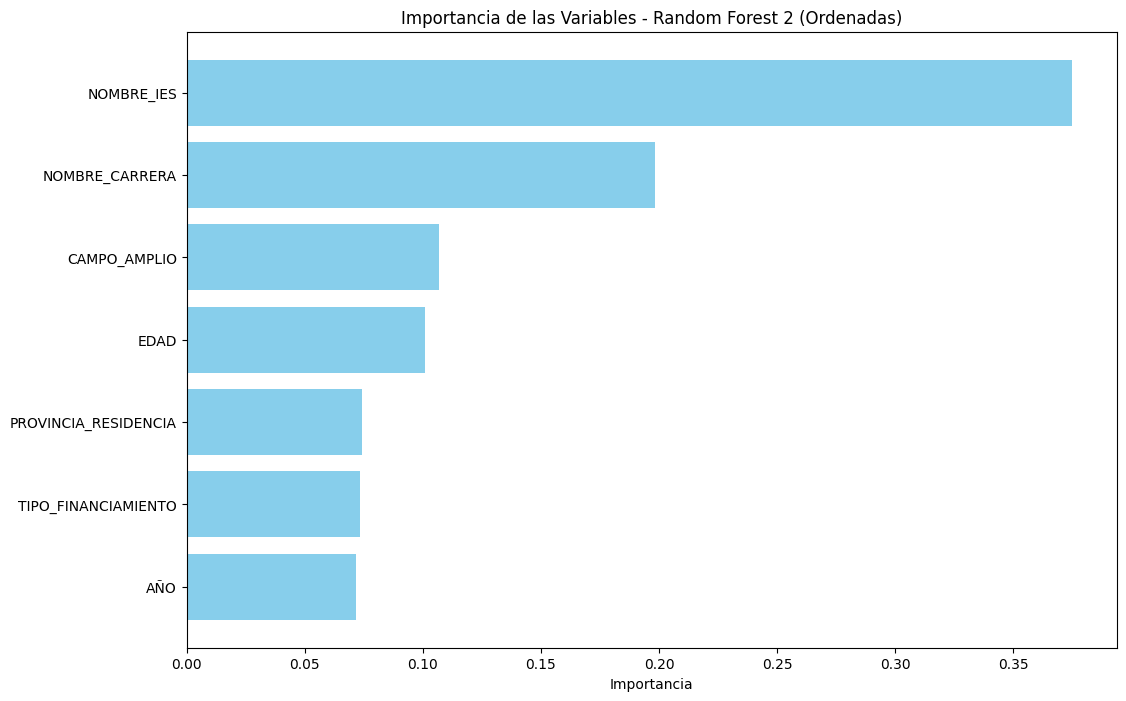

In [ ]:
# Obtener la importancia de las variables y los nombres
importances_2 = rf_model_2.feature_importances_
variables_2 = X_train_2.columns

# Ordenar las importancias de mayor a menor
importancia_ordenada, variables_ordenadas = zip(*sorted(zip(importances_2, variables_2), reverse=True))

# Graficar la importancia de las variables
plt.figure(figsize=(12, 8))
plt.barh(variables_ordenadas, importancia_ordenada, color='skyblue')
plt.xlabel('Importancia')
plt.title('Importancia de las Variables - Random Forest 2 (Ordenadas)')
plt.gca().invert_yaxis()  # Invertir el eje Y para mostrar las barras de mayor a menor
plt.show()

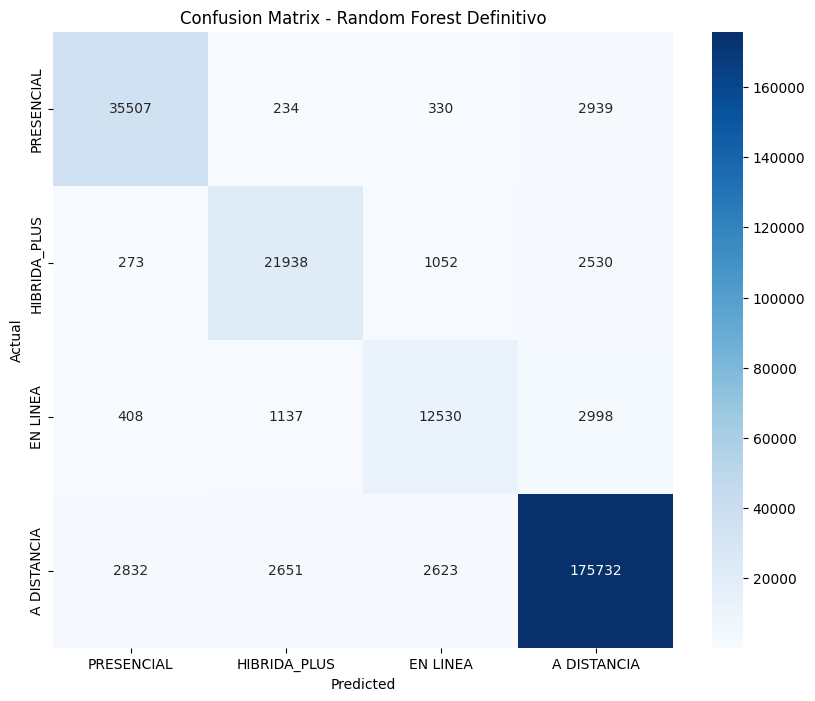

In [ ]:
# prompt: imprime la matriz de confusión del Random Forest Definitivo

# Assuming y_test_labels_2 and y_pred_labels_2 are defined from your RandomForestClassifier
# Example:
# y_pred_2 = rf_model_2.predict(X_test_2)

cm = confusion_matrix(y_test_labels_2, y_pred_labels_2)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=list(nombres_modalidades_combinadas.keys()),
            yticklabels=list(nombres_modalidades_combinadas.keys()))
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest Definitivo')
plt.show()

In [ ]:
# prompt: dame la ROC AUC del modelo 3.5 Random Forest Definitivo - Eliminando las variables poco significativas y unificando Modalidades
# Assuming y_test_2 and y_pred_2 are defined from your RandomForestClassifier
# Example:
# y_pred_2 = rf_model_2.predict_proba(X_test_2)

# Calculate ROC AUC for the Random Forest model
roc_auc_rf_2 = roc_auc_score(y_test_2, rf_model_2.predict_proba(X_test_2), multi_class='ovr')

print(f"ROC AUC score for Random Forest Definitivo: {roc_auc_rf_2:.2f}")

ROC AUC score for Random Forest Definitivo: 0.99


In [ ]:
df.head()

,AÑO,NOMBRE_IES,TIPO_FINANCIAMIENTO,NOMBRE_CARRERA,NIVEL_FORMACION,MODALIDAD,PROVINCIA_RESIDENCIA,ETNIA,DISCAPACIDAD,CAMPO_AMPLIO,SEXO,EDAD,MODALIDAD_BINARIA,MODALIDAD_LABEL,MODALIDAD_LABEL_2
0,2017,0,2,8,0,4,18,3,5,0,0,25,1,PRESENCIAL,PRESENCIAL
1,2016,0,2,8,0,4,18,3,5,0,0,26,1,PRESENCIAL,PRESENCIAL
2,2018,0,2,8,0,4,18,3,5,0,0,26,1,PRESENCIAL,PRESENCIAL
3,2017,0,2,8,0,4,18,3,5,0,1,27,1,PRESENCIAL,PRESENCIAL
4,2018,0,2,8,0,4,18,3,5,0,0,28,1,PRESENCIAL,PRESENCIAL
